In [1]:
import torch
import aux_functions as aux
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append('..')
from env import ROOT_DIR as root

%load_ext autoreload
%autoreload 2


In [ ]:
config = {
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),

    # Define your model names here
    'vae_prefix1': 'StandardVAE',
    'vae_prefix2': 'StandardVAE_b_2',
    'vae_prefix3': 'StandardVAE_b_0_5',
    'eavae_prefix1': 'EAVAE_softlaplace', 
    'eavae_prefix2': 'EAVAE_softlaplace_beta1_1_0_beta2_2_0',
    'eavae_prefix3': 'EAVAE_softlaplace_beta1_1_0_beta2_0_5',
    'eavae_prefix4': 'EAVAE_softlaplace_b1_2_b2_1',
    'eavae_prefix5': 'EAVAE_softlaplace_b1_0_5_b2_1',

    # whether to use posterior mean or sample for the scaling var
    # sample should be chosen for softlaplace prior
    'scaling_first_moment': 'sample', # 'mean' or 'sample'

    # whether to use mean of the reconstructionsss
    'use_mean': True,

    'savedir': os.path.join(root, 'figures/'),
}

path = '../eval_data/'

In [6]:
cmap_bright_vae_eavae = sns.color_palette(['#4477AA','#EE6677'],2)
cmap_pale_vae_eavae = sns.color_palette(['#BBCCEE','#FFCCCC'],2)
cmap_dark_vae_eavae = sns.color_palette(['#222255','#663333'],2)

color_vae = cmap_bright_vae_eavae[0]
color_vae_pale = cmap_pale_vae_eavae[0]
color_vae_dark = cmap_dark_vae_eavae[0]
color_eavae = cmap_bright_vae_eavae[1]
color_eavae_pale = cmap_pale_vae_eavae[1]
color_eavae_dark = cmap_dark_vae_eavae[1]

color_eavae1 = cmap_bright_vae_eavae[1]
color_eavae2 = cmap_dark_vae_eavae[1]
color_eavae3 = cmap_pale_vae_eavae[1]
color_eavae4 = cmap_dark_vae_eavae[1]
color_eavae5 = cmap_pale_vae_eavae[1]

color_vae1 = cmap_bright_vae_eavae[0]
color_vae2 = cmap_dark_vae_eavae[0]
color_vae3 = cmap_pale_vae_eavae[0]


# Figure S13

In [ ]:
#@title Load data

nat_contrast = aux.load(config['vae_prefix1'], 'contrast');
contrast_rounds_test_vae1 = aux.load(config['vae_prefix1'], 'contrast_rounds');
binned_signal_mean_test_vae1 = aux.load(config['vae_prefix1'], 'binned_signal_mean');
binned_signal_mean_error_test_vae1 = aux.load(config['vae_prefix1'], 'binned_signal_mean_error');
binned_signal_var_test_vae1 = aux.load(config['vae_prefix1'], 'binned_signal_var');
binned_signal_var_error_test_vae1 = aux.load(config['vae_prefix1'], 'binned_signal_var_error');
binned_noise_var_test_vae1 = aux.load(config['vae_prefix1'], 'binned_noise_var');
binned_noise_var_error_test_vae1 = aux.load(config['vae_prefix1'], 'binned_noise_var_error');

contrast_rounds_test_vae2 = aux.load(config['vae_prefix2'], 'contrast_rounds');
binned_signal_mean_test_vae2 = aux.load(config['vae_prefix2'], 'binned_signal_mean');
binned_signal_mean_error_test_vae2 = aux.load(config['vae_prefix2'], 'binned_signal_mean_error');
binned_signal_var_test_vae2 = aux.load(config['vae_prefix2'], 'binned_signal_var');
binned_signal_var_error_test_vae2 = aux.load(config['vae_prefix2'], 'binned_signal_var_error');
binned_noise_var_test_vae2 = aux.load(config['vae_prefix2'], 'binned_noise_var');
binned_noise_var_error_test_vae2 = aux.load(config['vae_prefix2'], 'binned_noise_var_error');

contrast_rounds_test_vae3 = aux.load(config['vae_prefix3'], 'contrast_rounds');
binned_signal_mean_test_vae3 = aux.load(config['vae_prefix3'], 'binned_signal_mean');
binned_signal_mean_error_test_vae3 = aux.load(config['vae_prefix3'], 'binned_signal_mean_error');
binned_signal_var_test_vae3 = aux.load(config['vae_prefix3'], 'binned_signal_var');
binned_signal_var_error_test_vae3 = aux.load(config['vae_prefix3'], 'binned_signal_var_error');
binned_noise_var_test_vae3 = aux.load(config['vae_prefix3'], 'binned_noise_var');
binned_noise_var_error_test_vae3 = aux.load(config['vae_prefix3'], 'binned_noise_var_error');

contrast_rounds_test_eavae1 = aux.load(config['eavae_prefix1'], 'contrast_rounds');
binned_signal_mean_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_signal_mean');
binned_signal_mean_error_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_signal_mean_error');
binned_signal_var_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_signal_var');
binned_signal_var_error_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_signal_var_error');
binned_noise_var_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_noise_var');
binned_noise_var_error_test_eavae1 = aux.load(config['eavae_prefix1'], 'binned_noise_var_error');
s1_post_sample = aux.load(config['eavae_prefix1'], f"posterior_{config['scaling_first_moment']}")[:, -1];

contrast_rounds_test_eavae2 = aux.load(config['eavae_prefix2'], 'contrast_rounds');
binned_signal_mean_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_signal_mean');
binned_signal_mean_error_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_signal_mean_error');
binned_signal_var_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_signal_var');
binned_signal_var_error_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_signal_var_error');
binned_noise_var_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_noise_var');
binned_noise_var_error_test_eavae2 = aux.load(config['eavae_prefix2'], 'binned_noise_var_error');
s2_post_sample = aux.load(config['eavae_prefix2'], f"posterior_{config['scaling_first_moment']}")[:, -1];


contrast_rounds_test_eavae3 = aux.load(config['eavae_prefix3'], 'contrast_rounds');
binned_signal_mean_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_signal_mean');
binned_signal_mean_error_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_signal_mean_error');
binned_signal_var_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_signal_var');
binned_signal_var_error_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_signal_var_error');
binned_noise_var_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_noise_var');
binned_noise_var_error_test_eavae3 = aux.load(config['eavae_prefix3'], 'binned_noise_var_error') ;
s3_post_sample = aux.load(config['eavae_prefix3'], f"posterior_{config['scaling_first_moment']}")[:, -1] ;

contrast_rounds_test_eavae4 = aux.load(config['eavae_prefix4'], 'contrast_rounds');
binned_signal_mean_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_signal_mean');
binned_signal_mean_error_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_signal_mean_error');
binned_signal_var_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_signal_var');
binned_signal_var_error_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_signal_var_error');
binned_noise_var_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_noise_var');
binned_noise_var_error_test_eavae4 = aux.load(config['eavae_prefix4'], 'binned_noise_var_error') ;
s4_post_sample = aux.load(config['eavae_prefix4'], f"scaling_variable_sample") ;

contrast_rounds_test_eavae5 = aux.load(config['eavae_prefix5'], 'contrast_rounds');
binned_signal_mean_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_signal_mean');
binned_signal_mean_error_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_signal_mean_error');
binned_signal_var_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_signal_var');
binned_signal_var_error_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_signal_var_error');
binned_noise_var_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_noise_var');
binned_noise_var_error_test_eavae5 = aux.load(config['eavae_prefix5'], 'binned_noise_var_error') ;
s5_post_sample = aux.load(config['eavae_prefix5'], f"scaling_variable_sample") ;

In [ ]:
signal_sample_s1 = s1_post_sample[:]
signal_sample_s2 = s2_post_sample[:]
signal_sample_s3 = s3_post_sample[:]
signal_sample_s4 = s4_post_sample[:]
signal_sample_s5 = s5_post_sample[:]

nat_contrast = nat_contrast.detach().cpu().numpy()
contrast_rounds = np.linspace(np.min(nat_contrast), np.max(nat_contrast), 101)

contrast_rounded = contrast_rounds[np.argmin(abs(np.subtract.outer(nat_contrast, contrast_rounds)), axis=1)]

binned_signal_sample_s1= np.zeros_like(contrast_rounds)
binned_signal_sample_s2= np.zeros_like(contrast_rounds)
binned_signal_sample_s3= np.zeros_like(contrast_rounds)
binned_signal_sample_s4= np.zeros_like(contrast_rounds)
binned_signal_sample_s5= np.zeros_like(contrast_rounds)
for k in range(len(contrast_rounds)):
    binned_signal_sample_s1[k] = signal_sample_s1[contrast_rounded == contrast_rounds[k]].mean()
    binned_signal_sample_s2[k] = signal_sample_s2[contrast_rounded == contrast_rounds[k]].mean()
    binned_signal_sample_s3[k] = signal_sample_s3[contrast_rounded == contrast_rounds[k]].mean()
    binned_signal_sample_s4[k] = signal_sample_s4[contrast_rounded == contrast_rounds[k]].mean()
    binned_signal_sample_s5[k] = signal_sample_s5[contrast_rounded == contrast_rounds[k]].mean()

binned_signal_sample_s1_error = np.zeros_like(contrast_rounds)
binned_signal_sample_s2_error = np.zeros_like(contrast_rounds)
binned_signal_sample_s3_error = np.zeros_like(contrast_rounds)
binned_signal_sample_s4_error = np.zeros_like(contrast_rounds)
binned_signal_sample_s5_error = np.zeros_like(contrast_rounds)

N = np.array([sum(contrast_rounded == contrast_rounds[k]) for k in range(len(contrast_rounds))])

for k in range(len(contrast_rounds)):
    binned_signal_sample_s1_error[k] = signal_sample_s1[contrast_rounded == contrast_rounds[k]].std() / np.sqrt(N[k])
    binned_signal_sample_s2_error[k] = signal_sample_s2[contrast_rounded == contrast_rounds[k]].std() / np.sqrt(N[k])
    binned_signal_sample_s3_error[k] = signal_sample_s3[contrast_rounded == contrast_rounds[k]].std() / np.sqrt(N[k])
    binned_signal_sample_s4_error[k] = signal_sample_s4[contrast_rounded == contrast_rounds[k]].std() / np.sqrt(N[k])
    binned_signal_sample_s5_error[k] = signal_sample_s5[contrast_rounded == contrast_rounds[k]].std() / np.sqrt(N[k])

In [28]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'DejaVu Sans'

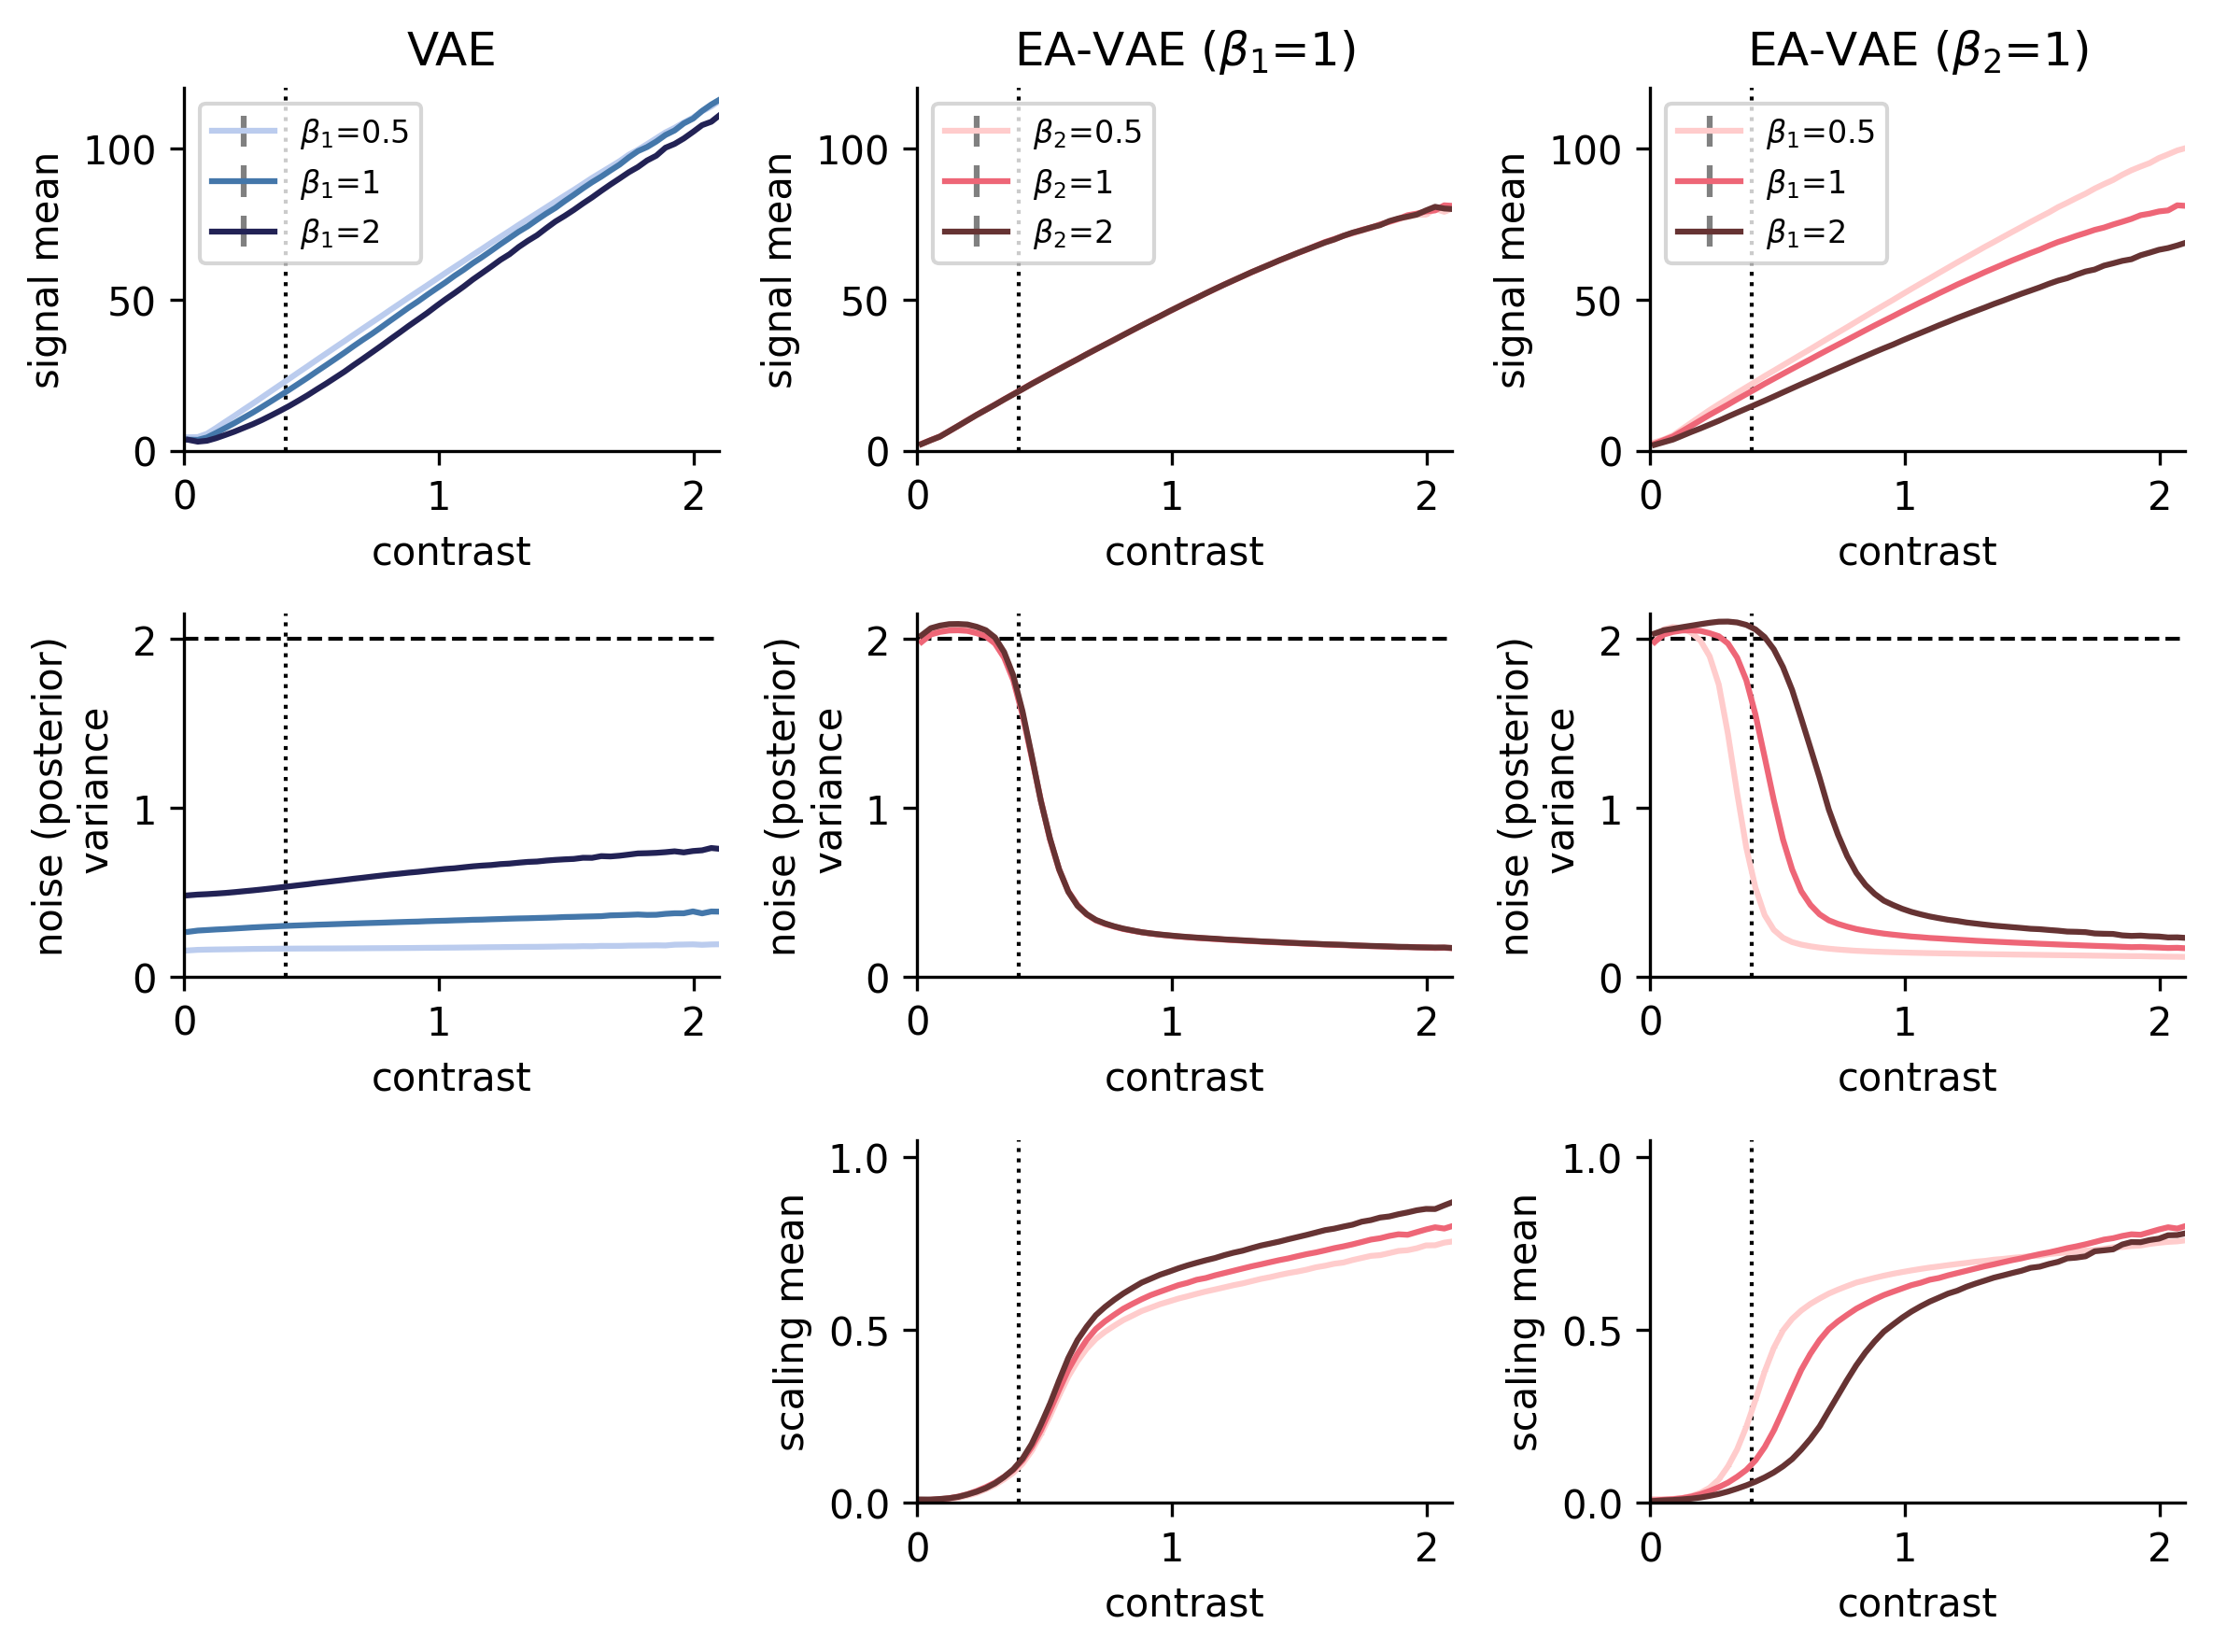

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(8,6))
ax[0,0].errorbar(x=contrast_rounds_test_vae3[:-1],y=binned_signal_mean_test_vae3[:-1],yerr=binned_signal_mean_error_test_vae3[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae3,zorder=1,label=r'$\beta_1$=0.5')#,label='VAE')#,label='test imgs')
ax[0,0].errorbar(x=contrast_rounds_test_vae1[:-1],y=binned_signal_mean_test_vae1[:-1],yerr=binned_signal_mean_error_test_vae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae1,zorder=1,label=r'$\beta_1$=1')#,label='VAE')#,label='test imgs')
ax[0,0].errorbar(x=contrast_rounds_test_vae2[:-1],y=binned_signal_mean_test_vae2[:-1],yerr=binned_signal_mean_error_test_vae2[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae2,zorder=1,label=r'$\beta_1$=2')#,label='VAE')#,label='test imgs')

ax[0,1].errorbar(x=contrast_rounds_test_eavae3[:-1],y=binned_signal_mean_test_eavae3[:-1],yerr=binned_signal_mean_error_test_eavae3[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae3,zorder=1,label=r'$\beta_2$=0.5')
ax[0,1].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_signal_mean_test_eavae1[:-1],yerr=binned_signal_mean_error_test_eavae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_2$=1')
ax[0,1].errorbar(x=contrast_rounds_test_eavae2[:-1],y=binned_signal_mean_test_eavae2[:-1],yerr=binned_signal_mean_error_test_eavae2[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae2,zorder=1,label=r'$\beta_2$=2')

ax[0,2].errorbar(x=contrast_rounds_test_eavae5[:-1],y=binned_signal_mean_test_eavae5[:-1],yerr=binned_signal_mean_error_test_eavae5[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae5,zorder=1,label=r'$\beta_1$=0.5')
ax[0,2].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_signal_mean_test_eavae1[:-1],yerr=binned_signal_mean_error_test_eavae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_1$=1')
ax[0,2].errorbar(x=contrast_rounds_test_eavae4[:-1],y=binned_signal_mean_test_eavae4[:-1],yerr=binned_signal_mean_error_test_eavae4[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae4,zorder=1,label=r'$\beta_1$=2')

ax[1,0].errorbar(x=contrast_rounds_test_vae3[:-1],y=binned_noise_var_test_vae3[:-1],yerr=binned_noise_var_error_test_vae3[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae3,zorder=1,label=r'$\beta_1$=0.5')#,label='VAE')#,label='test imgs')
ax[1,0].errorbar(x=contrast_rounds_test_vae1[:-1],y=binned_noise_var_test_vae1[:-1],yerr=binned_noise_var_error_test_vae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae1,zorder=1,label=r'$\beta_1$=1')#,label='VAE')#,label='test imgs')
ax[1,0].errorbar(x=contrast_rounds_test_vae2[:-1],y=binned_noise_var_test_vae2[:-1],yerr=binned_noise_var_error_test_vae2[:-1],ms=2,fmt='-',ecolor='gray',color=color_vae2,zorder=1,label=r'$\beta_1$=2')#,label='VAE')#,label='test imgs')

ax[1,1].errorbar(x=contrast_rounds_test_eavae3[:-1],y=binned_noise_var_test_eavae3[:-1],yerr=binned_noise_var_error_test_eavae3[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae3,zorder=1,label=r'$\beta_2$=0.5')
ax[1,1].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_noise_var_test_eavae1[:-1],yerr=binned_noise_var_error_test_eavae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_2$=1')
ax[1,1].errorbar(x=contrast_rounds_test_eavae2[:-1],y=binned_noise_var_test_eavae2[:-1],yerr=binned_noise_var_error_test_eavae2[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae2,zorder=1,label=r'$\beta_2$=2')

ax[1,2].errorbar(x=contrast_rounds_test_eavae5[:-1],y=binned_noise_var_test_eavae5[:-1],yerr=binned_noise_var_error_test_eavae5[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae5,zorder=1,label=r'$\beta_1$=0.5')
ax[1,2].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_noise_var_test_eavae1[:-1],yerr=binned_noise_var_error_test_eavae1[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_1$=1')
ax[1,2].errorbar(x=contrast_rounds_test_eavae4[:-1],y=binned_noise_var_test_eavae4[:-1],yerr=binned_noise_var_error_test_eavae4[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae4,zorder=1,label=r'$\beta_1$=2')

ax[2,1].errorbar(x=contrast_rounds_test_eavae3[:-1],y=binned_signal_sample_s3[:-1],yerr=binned_signal_sample_s3_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae3,zorder=1,label=r'$\beta_1$=0.5')
ax[2,1].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_signal_sample_s1[:-1],yerr=binned_signal_sample_s1_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_1$=1')
ax[2,1].errorbar(x=contrast_rounds_test_eavae2[:-1],y=binned_signal_sample_s2[:-1],yerr=binned_signal_sample_s2_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae2,zorder=1,label=r'$\beta_1$=2')

ax[2,2].errorbar(x=contrast_rounds_test_eavae5[:-1],y=binned_signal_sample_s5[:-1],yerr=binned_signal_sample_s5_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae5,zorder=1,label=r'$\beta_2$=0.5')
ax[2,2].errorbar(x=contrast_rounds_test_eavae1[:-1],y=binned_signal_sample_s1[:-1],yerr=binned_signal_sample_s1_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae1,zorder=1,label=r'$\beta_2$=1')
ax[2,2].errorbar(x=contrast_rounds_test_eavae4[:-1],y=binned_signal_sample_s4[:-1],yerr=binned_signal_sample_s4_error[:-1],ms=2,fmt='-',ecolor='gray',color=color_eavae4,zorder=1,label=r'$\beta_2$=2')

for j in range(3):
    ax[0, j].set_xlabel('contrast')
    ax[0, j].set_ylabel('signal mean')    
    ax[1, j].set_xlabel('contrast')
    ax[1, j].set_ylabel('noise (posterior)\n variance')
for j in range(2):
    ax[2, j+1].set_xlabel('contrast')
    ax[2, j+1].set_ylabel('scaling mean')

ax[0,0].set_title(r'VAE')
ax[0,1].set_title(r'EA-VAE ($\beta_1$=1)')
ax[0,2].set_title(r'EA-VAE ($\beta_2$=1)')

for i in range(3):
    ax[0,i].set_xlim(0,2.1)
    ax[1,i].set_xlim(0,2.1)
    ax[2,i].set_xlim(0,2.1)

    ax[0,i].set_xticks([0,1,2])
    ax[1,i].set_xticks([0,1,2])
    ax[2,i].set_xticks([0,1,2])


for j in range(3):
    ax[1,j].axhline(2,color='black',ls='--',zorder= 0,lw=1)
    ax[0,j].set_ylim(0.0,120)
    ax[1,j].set_ylim(0.0,2.15)
    ax[2,j].set_ylim(0.0,1.05)
    
for j in range(2):
    ax[2,j+1].axvline(0.4, color='black', ls=':', lw=1, zorder=0)
    ax[1,j+1].axvline(0.4, color='black', ls=':', lw=1, zorder=0)
    ax[0,j+1].axvline(0.4, color='black', ls=':', lw=1, zorder=0)
    ax[j,0].axvline(0.4, color='black', ls=':', lw=1, zorder=0)

ax[1,0].set_yticks([0,1,2])
ax[1,1].set_yticks([0,1,2])
ax[1,2].set_yticks([0,1,2])
ax[2,1].set_yticks([0,0.5,1])
ax[2,2].set_yticks([0,0.5,1])

for a in ax.flat:
    a.spines[['right', 'top']].set_visible(False)

ax[2,0].spines[['right', 'top', 'left', 'bottom']].set_visible(False)
ax[2,0].set_xticks([])
ax[2,0].set_yticks([])

ax[0,0].legend(loc = 'upper left', frameon=True, fontsize=8)
ax[0,1].legend(loc = 'upper left', frameon=True, fontsize=8)
ax[0,2].legend(loc = 'upper left', frameon=True, fontsize=8)

plt.tight_layout()

aux.save_fig(config['savedir']+"beta_comparison",format='pdf')

In [70]:
nat_contrast = aux.load(config['vae_prefix'], 'contrast')

s1_post_mean = aux.load(config['eavae_prefix1'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s1_post_std = aux.load(config['eavae_prefix1'], f"posterior_std")[:, -1]
s1_post_sample = aux.load(config['eavae_prefix1'], f"posterior_sample")[:, -1]

s2_post_mean = aux.load(config['eavae_prefix2'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s2_post_std = aux.load(config['eavae_prefix2'], f"posterior_std")[:, -1]
s2_post_sample = aux.load(config['eavae_prefix2'], f"posterior_sample")[:, -1]

s3_post_mean = aux.load(config['eavae_prefix3'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s3_post_std = aux.load(config['eavae_prefix3'], f"posterior_std")[:, -1]
s3_post_sample = aux.load(config['eavae_prefix3'], f"posterior_sample")[:, -1]

File loaded from ../eval_data/StandardVAE/StandardVAE_contrast.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1

In [ ]:
nat_contrast = aux.load(config['vae_prefix'], 'contrast');
vae_post_mean = aux.get_active_dims(([config['vae_prefix'], 'posterior_mean']));
vae_post_std = aux.get_active_dims(([config['vae_prefix'], 'posterior_std']));

eavae1_post_mean = aux.get_active_dims(([config['eavae_prefix1'], 'posterior_mean']));
eavae1_post_std = aux.get_active_dims(([config['eavae_prefix1'], 'posterior_std']));
s1_post_mean = aux.load(config['eavae_prefix1'], f"posterior_{config['scaling_first_moment']}")[:, -1];

eavae2_post_mean = aux.get_active_dims(([config['eavae_prefix2'], 'posterior_mean']));
eavae2_post_std = aux.get_active_dims(([config['eavae_prefix2'], 'posterior_std']));
s2_post_mean = aux.load(config['eavae_prefix2'], f"posterior_{config['scaling_first_moment']}")[:, -1];

eavae3_post_mean = aux.get_active_dims(([config['eavae_prefix3'], 'posterior_mean']));
eavae3_post_std = aux.get_active_dims(([config['eavae_prefix3'], 'posterior_std']));
s3_post_mean = aux.load(config['eavae_prefix3'], f"posterior_{config['scaling_first_moment']}")[:, -1] ;


File loaded from ../eval_data/StandardVAE/StandardVAE_contrast.pt
File loaded from ../eval_data/StandardVAE/StandardVAE_posterior_mean.pt
['StandardVAE', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/StandardVAE/StandardVAE_posterior_mean.pt
File loaded from ../eval_data/StandardVAE/StandardVAE_posterior_std.pt
['StandardVAE', 'posterior_std'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_mean.pt
['EAVAE_softlaplace', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_mean.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_std.pt
['EAVAE_softlaplace', 'posterior_std'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_mean.pt
['EAVAE_softlapl

## Panel 1f

In [15]:
vae_rec = aux.load(config['vae_prefix'], 'reconstruction')
eavae1_rec = aux.load(config['eavae_prefix1'], 'reconstruction')
eavae2_rec = aux.load(config['eavae_prefix2'], 'reconstruction')
eavae3_rec = aux.load(config['eavae_prefix3'], 'reconstruction')

ind = 2 if config['use_mean'] else 1
print(f'With use_mean = {config["use_mean"]}')
x_ori, x_vae = vae_rec[0], vae_rec[ind]
x_eavae1 = eavae1_rec[ind]
x_eavae2 = eavae2_rec[ind]
x_eavae3 = eavae3_rec[ind]

contrasts = torch.std(x_ori, dim=(1,2,3))
contrasts_sorted, contrasts_sorted_idx = torch.sort(contrasts)

File loaded from ../eval_data/StandardVAE/StandardVAE_reconstruction.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_reconstruction.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_reconstruction.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_reconstruction.pt
With use_mean = True


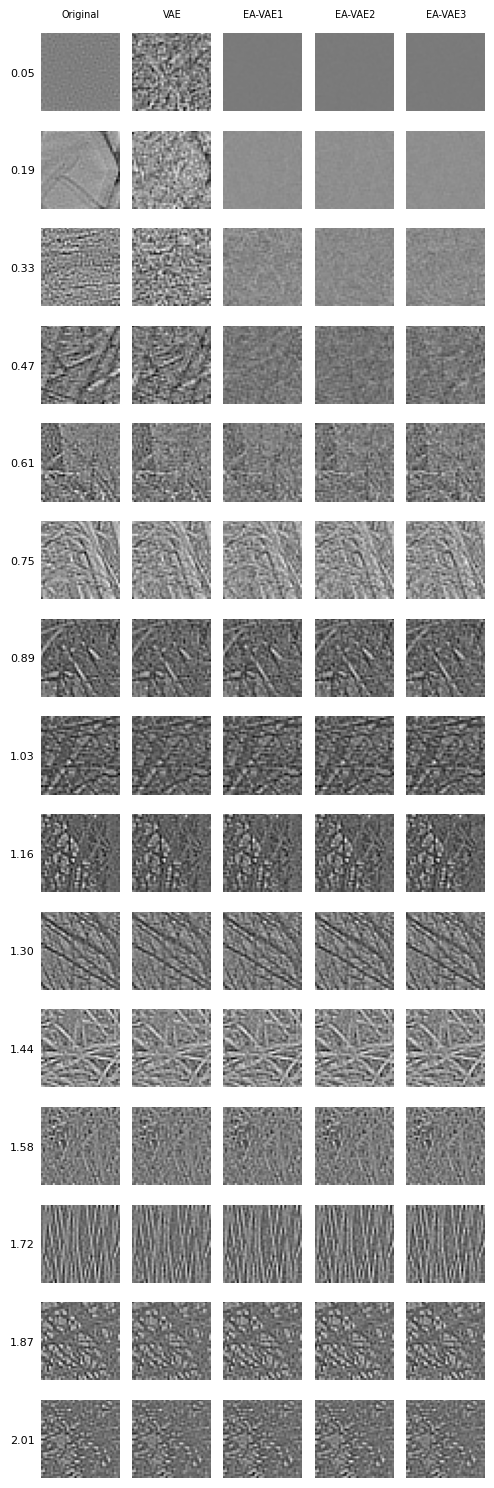

In [ ]:
num_images = 15
min_contrast, max_contrast = 0.05, 2

fig, ax = plt.subplots(num_images, 5, figsize=(5, num_images))
values = torch.linspace(min_contrast, max_contrast, num_images)

ax[0,0].text(20, -10, 'Original', fontsize=7, horizontalalignment='center', verticalalignment='center')
ax[0,1].text(20, -10, 'VAE', fontsize=7, horizontalalignment='center', verticalalignment='center')
ax[0,2].text(20, -10, 'EA-VAE1', fontsize=7, horizontalalignment='center', verticalalignment='center')
ax[0,3].text(20, -10, 'EA-VAE2', fontsize=7, horizontalalignment='center', verticalalignment='center')
ax[0,4].text(20, -10, 'EA-VAE3', fontsize=7, horizontalalignment='center', verticalalignment='center')
e
for k in range(num_images):
    threshold = values[k]
    ratio = torch.where(contrasts_sorted > threshold)[0][0].item()
    ind = contrasts_sorted_idx[ratio]
    vminn = np.array([x_ori[ind].min(),x_vae[ind].min(),x_eavae1[ind].min(),x_eavae2[ind].min(),x_eavae3[ind].min()]).min()
    vmaxx = np.array([x_ori[ind].max(),x_vae[ind].max(),x_eavae1[ind].max(),x_eavae2[ind].max(),x_eavae3[ind].max()]).max()
    ax[k,0].imshow(x_ori[ind].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[k,0].axis("off")
    ax[k,0].set_aspect("equal")
    ax[k,0].text(-10, 20, f'{x_ori[ind].std():.2f}', horizontalalignment='center', verticalalignment='center', fontsize=8)
    ax[k,1].imshow(x_vae[ind].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[k,1].axis("off")
    ax[k,1].set_aspect("equal")
    ax[k,2].imshow(x_eavae1[ind].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[k,2].axis("off")
    ax[k,2].set_aspect("equal")
    ax[k,3].imshow(x_eavae2[ind].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[k,3].axis("off")
    ax[k,3].set_aspect("equal")
    ax[k,4].imshow(x_eavae3[ind].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[k,4].axis("off")
    ax[k,4].set_aspect("equal")

fig.tight_layout()

#aux.save_fig(config['savedir']+"vae_eavae_reconstruction")

/tmp/ipykernel_1457493/1217242665.py:33: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


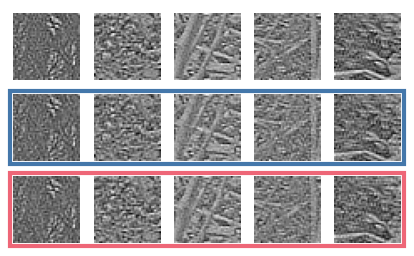

In [9]:
hi_contrast_idx = np.where(x_ori.std(dim=(1,2,3)) > 0.75)
x_ori_hi = x_ori[hi_contrast_idx]
x_vae_hi = x_vae[hi_contrast_idx]
x_eavae_hi = x_eavae[hi_contrast_idx]

fig, ax = plt.subplots(3, 5, figsize=(5,3))
rect_ori = plt.Rectangle((-2.5,-0.05), width=236, height=1.1,
                     transform=ax[0,0].get_xaxis_transform(), clip_on=False,
                     facecolor="none", linewidth=3)
rect_eavae = plt.Rectangle((-2.5,-0.05), width=236, height=1.1,
                     transform=ax[2,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae, facecolor="none", linewidth=3)
rect_vae = plt.Rectangle((-2.5,-0.05), width=236, height=1.1,
                     transform=ax[1,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_vae, facecolor="none", linewidth=3)
ax[0,0].add_patch(rect_ori)
ax[1,0].add_patch(rect_vae)
ax[2,0].add_patch(rect_eavae)
for i,k in enumerate(range(6,11)):

    vminn = np.array([x_ori_hi[k].min(),x_vae_hi[k].min(),x_eavae_hi[k].min()]).min()
    vmaxx = np.array([x_ori_hi[k].max(),x_vae_hi[k].max(),x_eavae_hi[k].max()]).max()
    ax[0, i].imshow(x_ori_hi[k].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[0, i].axis("off")
    ax[0, i].set_aspect("equal")
    ax[1, i].imshow(x_vae_hi[k].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[1, i].axis("off")
    ax[1, i].set_aspect("equal")
    ax[2, i].imshow(x_eavae_hi[k].reshape(40,40).squeeze(), aspect="auto", cmap='gray',vmin=vminn,vmax=vmaxx)
    ax[2, i].axis("off")
    ax[2, i].set_aspect("equal")

plt.tight_layout()

aux.save_fig(config['savedir']+"vae_eavae_reconstruction_fig1")

## Panel 1g

In [17]:
informative_idxs_vae = aux.get_active_dims([config['vae_prefix'], 'posterior_mean'], only_mask=True)
informative_idxs_eavae1 = aux.get_active_dims([config['eavae_prefix1'], 'posterior_mean'], only_mask=True)
informative_idxs_eavae2 = aux.get_active_dims([config['eavae_prefix2'], 'posterior_mean'], only_mask=True)
informative_idxs_eavae3 = aux.get_active_dims([config['eavae_prefix3'], 'posterior_mean'], only_mask=True)

vae_pf = torch.tensor(aux.load(config['vae_prefix'], 'projective_fields'))
eavae1_pf = torch.tensor(aux.load(config['eavae_prefix1'], 'projective_fields'))
eavae2_pf = torch.tensor(aux.load(config['eavae_prefix2'], 'projective_fields'))
eavae3_pf = torch.tensor(aux.load(config['eavae_prefix3'], 'projective_fields'))

vae_pf_active = vae_pf[informative_idxs_vae]
eavae1_pf_active = eavae1_pf[informative_idxs_eavae1]
eavae2_pf_active = eavae2_pf[informative_idxs_eavae2]
eavae3_pf_active = eavae3_pf[informative_idxs_eavae3]
# passive dimensions (not in informative_idxs)
vae_pf_passive = vae_pf[~informative_idxs_vae]
eavae1_pf_passive = eavae1_pf[~informative_idxs_eavae1]
eavae2_pf_passive = eavae2_pf[~informative_idxs_eavae2]
eavae3_pf_passive = eavae3_pf[~informative_idxs_eavae3]

File loaded from ../eval_data/StandardVAE/StandardVAE_posterior_mean.pt
['StandardVAE', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_mean.pt
['EAVAE_softlaplace', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_mean.pt
['EAVAE_softlaplace_beta1_1_0_beta2_2_0', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_posterior_mean.pt
['EAVAE_softlaplace_beta1_1_0_beta2_0_5', 'posterior_mean'] # of active dims:  1256
File loaded from ../eval_data/StandardVAE/StandardVAE_projective_fields.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_projective_fields.pt


/tmp/ipykernel_26083/2690169179.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  vae_pf = torch.tensor(aux.load(config['vae_prefix'], 'projective_fields'))


File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_projective_fields.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_projective_fields.pt


/tmp/ipykernel_26083/550327555.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


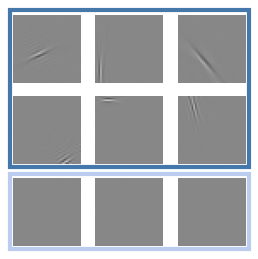

In [18]:
nrows,ncols= 3,3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols,nrows),facecolor='white')
rect_vae_inf = plt.Rectangle((-2.5,-0.05), width=140.5, height=2.325,
                     transform=axs[1,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_vae, facecolor="none", linewidth=3)
rect_vae_dec = plt.Rectangle((-2.5,-0.05), width=140.5, height=1.1,
                     transform=axs[2,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_vae_pale, facecolor="none", linewidth=3)
axs[1,0].add_patch(rect_vae_inf)
axs[2,0].add_patch(rect_vae_dec)
for ind,ax in enumerate(axs.ravel()):
    if ind < 2*ncols:
        ind = np.random.randint(0,1256)
        img = vae_pf_active[ind, :]
    else:
        img = vae_pf_passive[ind, :]
    ax.imshow(img.reshape(40,40), cmap="gray",vmin=vae_pf.min(),vmax = vae_pf.max())
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

#aux.save_fig(config['savedir']+"vae_projective_fields_fig1")

/tmp/ipykernel_26083/1265859830.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


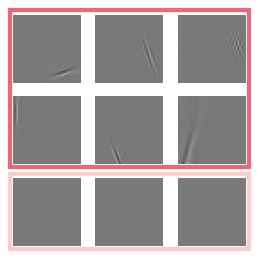

In [19]:
nrows,ncols= 3,3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols,nrows),facecolor='white')
rect_eavae_inf = plt.Rectangle((-2.5,-0.05), width=140.5, height=2.325,
                     transform=axs[1,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae, facecolor="none", linewidth=3)
rect_eavae_dec = plt.Rectangle((-2.5,-0.05), width=140.5, height=1.1,
                     transform=axs[2,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae_pale, facecolor="none", linewidth=3)
axs[1,0].add_patch(rect_eavae_inf)
axs[2,0].add_patch(rect_eavae_dec)
for ind,ax in enumerate(axs.ravel()):
    if ind < 2*ncols:
        #ind = np.random.randint(0,1256)
        img = eavae1_pf_active[ind, :]
    else:
        img = eavae1_pf_passive[ind, :]
    ax.imshow(img.reshape(40,40), cmap="gray",vmin=eavae1_pf.min(),vmax = eavae1_pf.max())
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

#aux.save_fig(config['savedir']+"eavae_projective_fields_fig1")

/tmp/ipykernel_26083/2401578268.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


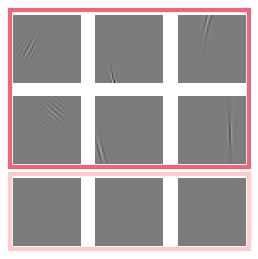

In [20]:
nrows,ncols= 3,3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols,nrows),facecolor='white')
rect_eavae_inf = plt.Rectangle((-2.5,-0.05), width=140.5, height=2.325,
                     transform=axs[1,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae, facecolor="none", linewidth=3)
rect_eavae_dec = plt.Rectangle((-2.5,-0.05), width=140.5, height=1.1,
                     transform=axs[2,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae_pale, facecolor="none", linewidth=3)
axs[1,0].add_patch(rect_eavae_inf)
axs[2,0].add_patch(rect_eavae_dec)
for ind,ax in enumerate(axs.ravel()):
    if ind < 2*ncols:
        #ind = np.random.randint(0,1256)
        img = eavae2_pf_active[ind, :]
    else:
        img = eavae2_pf_passive[ind, :]
    ax.imshow(img.reshape(40,40), cmap="gray",vmin=eavae2_pf.min(),vmax = eavae2_pf.max())
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

#aux.save_fig(config['savedir']+"eavae_projective_fields_fig1")

/tmp/ipykernel_26083/1221508692.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


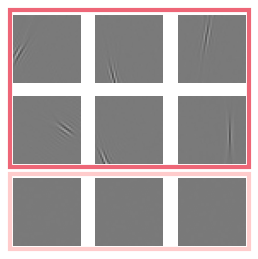

In [21]:
nrows,ncols= 3,3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols,nrows),facecolor='white')
rect_eavae_inf = plt.Rectangle((-2.5,-0.05), width=140.5, height=2.325,
                     transform=axs[1,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae, facecolor="none", linewidth=3)
rect_eavae_dec = plt.Rectangle((-2.5,-0.05), width=140.5, height=1.1,
                     transform=axs[2,0].get_xaxis_transform(), clip_on=False,
                     edgecolor=color_eavae_pale, facecolor="none", linewidth=3)
axs[1,0].add_patch(rect_eavae_inf)
axs[2,0].add_patch(rect_eavae_dec)
for ind,ax in enumerate(axs.ravel()):
    if ind < 2*ncols:
        #ind = np.random.randint(0,1256)
        img = eavae3_pf_active[ind, :]
    else:
        img = eavae3_pf_passive[ind, :]
    ax.imshow(img.reshape(40,40), cmap="gray",vmin=eavae3_pf.min(),vmax = eavae3_pf.max())
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

#aux.save_fig(config['savedir']+"eavae_projective_fields_fig1")

In [42]:
nat_contrast = aux.load(config['vae_prefix'], 'contrast')

s1_post_mean = aux.load(config['eavae_prefix1'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s1_post_std = aux.load(config['eavae_prefix1'], f"posterior_std")[:, -1]
s1_post_sample = aux.load(config['eavae_prefix1'], f"posterior_sample")[:, -1]

s2_post_mean = aux.load(config['eavae_prefix2'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s2_post_std = aux.load(config['eavae_prefix2'], f"posterior_std")[:, -1]
s2_post_sample = aux.load(config['eavae_prefix2'], f"posterior_sample")[:, -1]

s3_post_mean = aux.load(config['eavae_prefix3'], f"posterior_{config['scaling_first_moment']}")[:, -1]
s3_post_std = aux.load(config['eavae_prefix3'], f"posterior_std")[:, -1]
s3_post_sample = aux.load(config['eavae_prefix3'], f"posterior_sample")[:, -1]

/home/jcatoni/PhD/EA-VAE-natural-domain/evaluate/aux_functions.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(file_name)


File loaded from ../eval_data/StandardVAE/StandardVAE_contrast.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace/EAVAE_softlaplace_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_2_0/EAVAE_softlaplace_beta1_1_0_beta2_2_0_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_posterior_sample.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1_0_beta2_0_5/EAVAE_softlaplace_beta1_1_0_beta2_0_5_posterior_std.pt
File loaded from ../eval_data/EAVAE_softlaplace_beta1_1

/tmp/ipykernel_893944/620567938.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter(nat_contrast[:5000], eavae2_post_std.mean(axis=1)[:5000], s=1, c=color_eavae2,alpha=1,label=r'$\beta_1$=1, $\beta_2$=2')
/tmp/ipykernel_893944/620567938.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter(nat_contrast[:5000], eavae1_post_std.mean(axis=1)[:5000], s=1, c=color_eavae1,alpha=1,label=r'$\beta_1$=1, $\

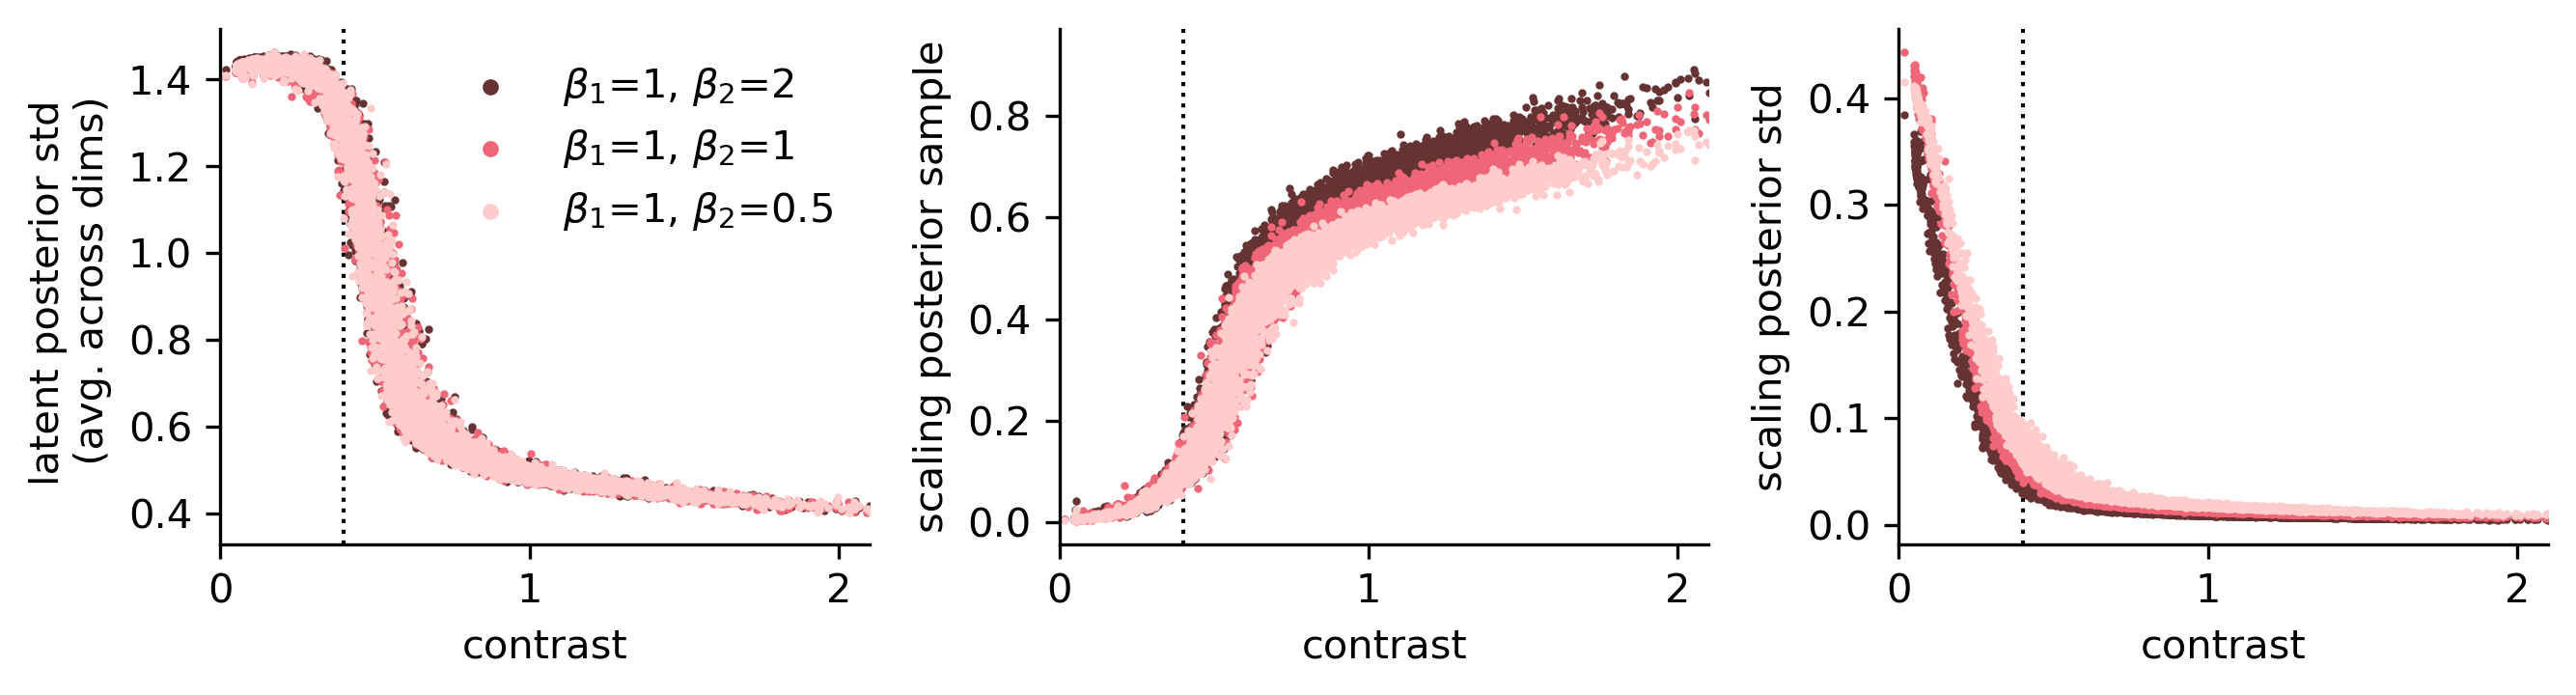

In [9]:
# eavae scaling posterior over contrast of images

fig, axs = plt.subplots(1, 3, figsize=(9, 2.5))

axs[0].scatter(nat_contrast[:5000], eavae2_post_std.mean(axis=1)[:5000], s=1, c=color_eavae2,alpha=1,label=r'$\beta_1$=1, $\beta_2$=2')
axs[0].scatter(nat_contrast[:5000], eavae1_post_std.mean(axis=1)[:5000], s=1, c=color_eavae1,alpha=1,label=r'$\beta_1$=1, $\beta_2$=1')
axs[0].scatter(nat_contrast[:5000], eavae3_post_std.mean(axis=1)[:5000], s=1, c=color_eavae3,alpha=1,label=r'$\beta_1$=1, $\beta_2$=0.5')
axs[0].set_xlabel('contrast')
axs[0].set_ylabel('latent posterior std \n (avg. across dims)')
axs[0].spines[['right', 'top']].set_visible(False)

axs[1].scatter(nat_contrast[:5000], s2_post_sample[:5000], s=1, c=color_eavae2,alpha=1)
axs[1].scatter(nat_contrast[:5000], s1_post_sample[:5000], s=1, c=color_eavae1,alpha=1)
axs[1].scatter(nat_contrast[:5000], s3_post_sample[:5000], s=1, c=color_eavae3,alpha=1)
axs[1].set_xlabel('contrast')
axs[1].set_ylabel('scaling posterior sample')
axs[1].spines[['right', 'top']].set_visible(False)

axs[2].scatter(nat_contrast[:5000], s3_post_std[:5000], s=1, c=color_eavae2,alpha=1)
axs[2].scatter(nat_contrast[:5000], s1_post_std[:5000], s=1, c=color_eavae1,alpha=1)
axs[2].scatter(nat_contrast[:5000], s2_post_std[:5000], s=1, c=color_eavae3,alpha=1)
axs[2].set_xlabel('contrast')
axs[2].set_ylabel('scaling posterior std')
axs[2].spines[['right', 'top']].set_visible(False)

# add dotted vertical line to both plots at x=0.4
for ax in axs:
    # axvline to background
    ax.axvline(0.4, color='black', linestyle='dotted', linewidth=1, zorder=0)
    ax.set_xlim(0, 2.1)
    ax.set_xticks([0, 1, 2])

axs[0].legend(loc='upper right', frameon=False, fontsize=10,markerscale=3.0)
plt.tight_layout()

#aux.save_fig(config['savedir']+"eavae_scaling_posterior_5000pts")